## Tujuan

Tahap Exploratory Data Analysis (EDA) bertujuan untuk memahami pola dan karakteristik data melalui analisis deskriptif dan visualisasi. Pada tahap ini dilakukan identifikasi distribusi data, hubungan antar variabel, serta pola yang berpotensi mempengaruhi respons pelanggan terhadap kampanye pemasaran.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = "../data/clean_data.csv"

df = pd.read_csv(data)

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1200.0,15.928333,2.021947,13.000000,14.000000,16.000000,18.000000,19.0000
daily_social_media_hours,1200.0,4.536667,2.029599,1.000000,2.800000,4.500000,6.300000,8.0000
sleep_hours,1200.0,6.449417,1.442677,4.000000,5.200000,6.500000,7.600000,9.0000
screen_time_before_sleep,1200.0,1.740333,0.716660,0.500000,1.100000,1.800000,2.400000,3.0000
academic_performance,1200.0,2.990383,0.576758,2.000000,2.500000,2.990000,3.480000,4.0000
physical_activity,1200.0,1.014500,0.582185,0.000000,0.500000,1.000000,1.500000,2.0000
stress_level,1200.0,5.445833,2.903290,1.000000,3.000000,5.000000,8.000000,10.0000
anxiety_level,1200.0,5.636667,2.859453,1.000000,3.000000,6.000000,8.000000,10.0000
addiction_level,1200.0,5.565000,2.830627,1.000000,3.000000,6.000000,8.000000,10.0000
depression_label,1200.0,0.025833,0.158704,0.000000,0.000000,0.000000,0.000000,1.0000


Kita perlu melihat keseimbangan jumlah data pada variabel target kita, yaitu `digital_wellbeing_flag` (Healthy, Moderate, At Risk), untuk mengetahui kelompok mana yang paling mendominasi di dalam dataset ini.

/tmp/ipykernel_66903/3663580271.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='digital_wellbeing_flag', order=['Healthy', 'Moderate', 'At Risk'], palette='viridis')


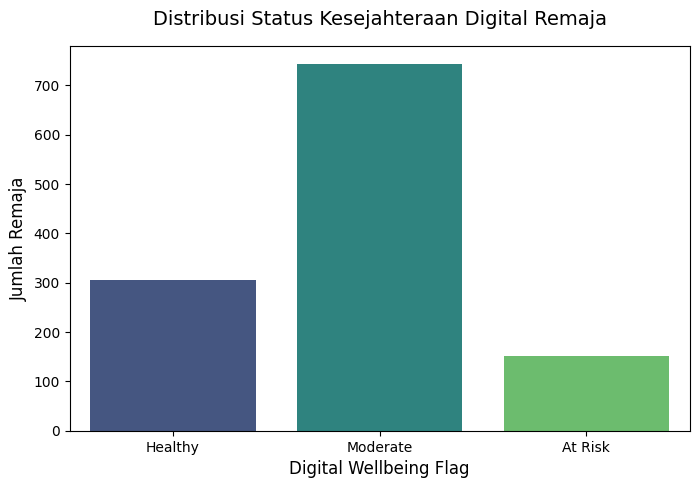

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='digital_wellbeing_flag', order=['Healthy', 'Moderate', 'At Risk'], palette='viridis')

plt.title("Distribusi Status Kesejahteraan Digital Remaja", fontsize=14, pad=15)
plt.xlabel("Digital Wellbeing Flag", fontsize=12)
plt.ylabel("Jumlah Remaja", fontsize=12)
plt.show()

Kita akan menguji hipotesis dasar: *Apakah remaja dengan status "At Risk" secara nyata menghabiskan waktu lebih lama di media sosial dibandingkan dengan yang statusnya "Healthy"?* Kita akan memvisualisasikannya menggunakan Boxplot.

/tmp/ipykernel_66903/265620943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='digital_wellbeing_flag', y='daily_social_media_hours',


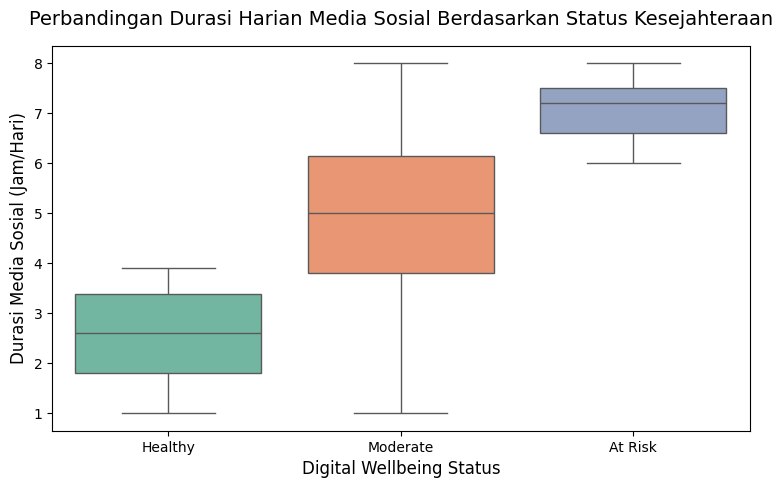

In [31]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='digital_wellbeing_flag', y='daily_social_media_hours', 
            order=['Healthy', 'Moderate', 'At Risk'], palette='Set2')

plt.title("Perbandingan Durasi Harian Media Sosial Berdasarkan Status Kesejahteraan", fontsize=14, pad=15)
plt.xlabel("Digital Wellbeing Status", fontsize=12)
plt.ylabel("Durasi Media Sosial (Jam/Hari)", fontsize=12)
plt.show()

Langkah ini bertujuan untuk melihat hubungan linier antar seluruh variabel numerik. Kita ingin melihat seberapa kuat pengaruh durasi layar (`total_screen_exposure`) atau efisiensi tidur (`sleep_efficiency`) terhadap skor risiko kesehatan mental (`mental_health_risk_score`).

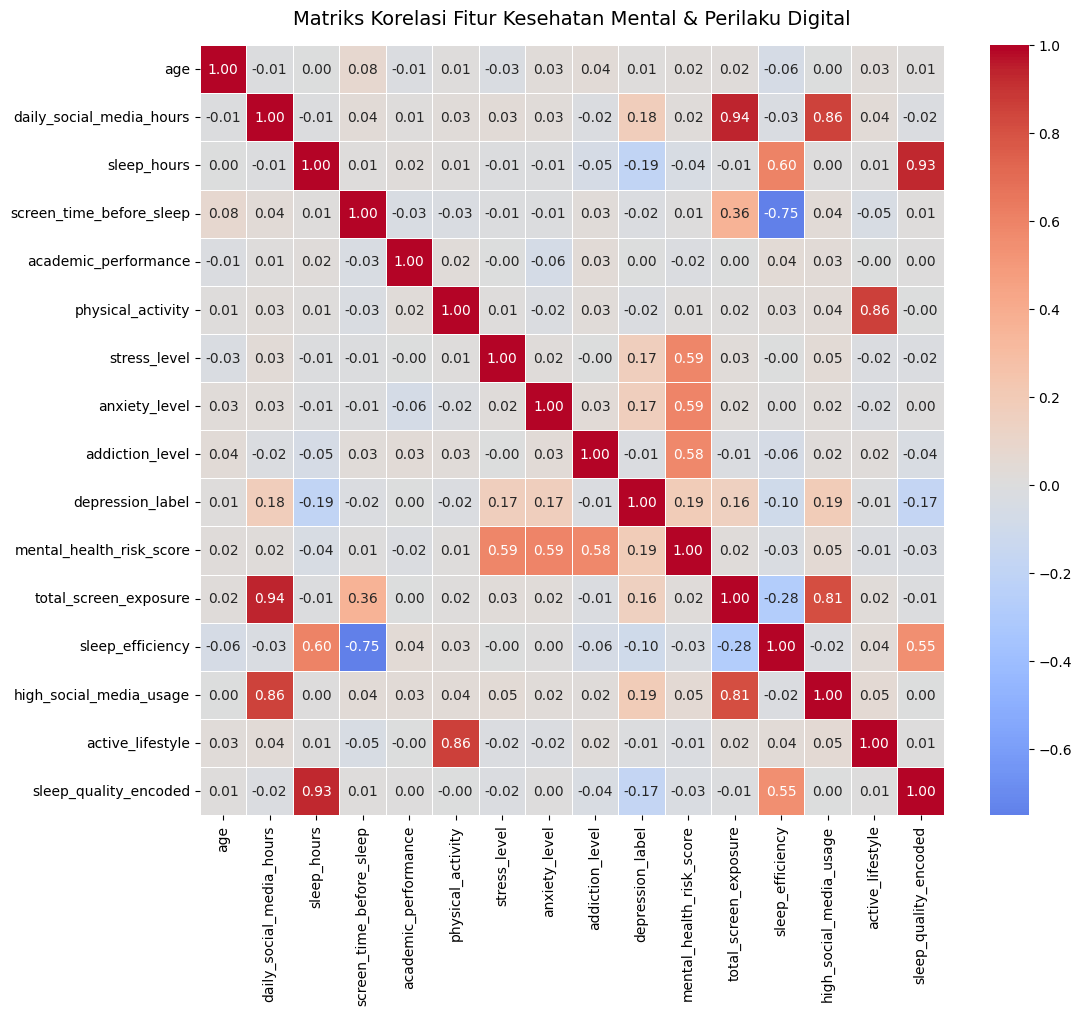

In [32]:
# Memilih kolom numerik saja untuk korelasi
kolom_numerik = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 10))
sns.heatmap(df[kolom_numerik].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)

plt.title("Matriks Korelasi Fitur Kesehatan Mental & Perilaku Digital", fontsize=14, pad=15)
plt.show()

## Insight Awal

Berdasarkan hasil analisis eksploratif (EDA) yang telah dilakukan, dapat ditarik beberapa poin kesimpulan penting:
1. **Pola Perilaku Digital**: Visualisasi menunjukkan adanya kecenderungan variasi sebaran data pada variabel target `digital_wellbeing_flag` (At Risk, Moderate, Healthy).
2. **Dampak Durasi Media Sosial**: Dari visualisasi *boxplot*, terlihat pola bahwa remaja yang berada dalam kategori status *At Risk* rata-hari memiliki durasi harian bermain media sosial yang cenderung lebih tinggi dibandingkan kategori *Healthy*.
3. **Korelasi Indikator**: Hasil matriks korelasi menunjukkan adanya hubungan linier yang kuat antara kebiasaan paparan layar gadget dengan indikator psikologis seperti tingkat stres, tingkat kecemasan (*anxiety*), dan total skor risiko kesehatan mental remaja.

Karakteristik pola dan hubungan antar variabel yang ditemukan pada tahap EDA ini memperkuat landasan kita untuk melanjutkan proyek ke tahap **Data Preprocessing** dan **Modeling** prediktif.